In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data/engineered_movies_dataset.csv')

Which genre is the safest bet for a new filmmaker

### Goal: Find out which genres yield the highest Return on Investment (ROI).

C:\Users\ANISH\AppData\Local\Temp\ipykernel_38276\1967218719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_roi.values, y=genre_roi.index, palette="viridis")


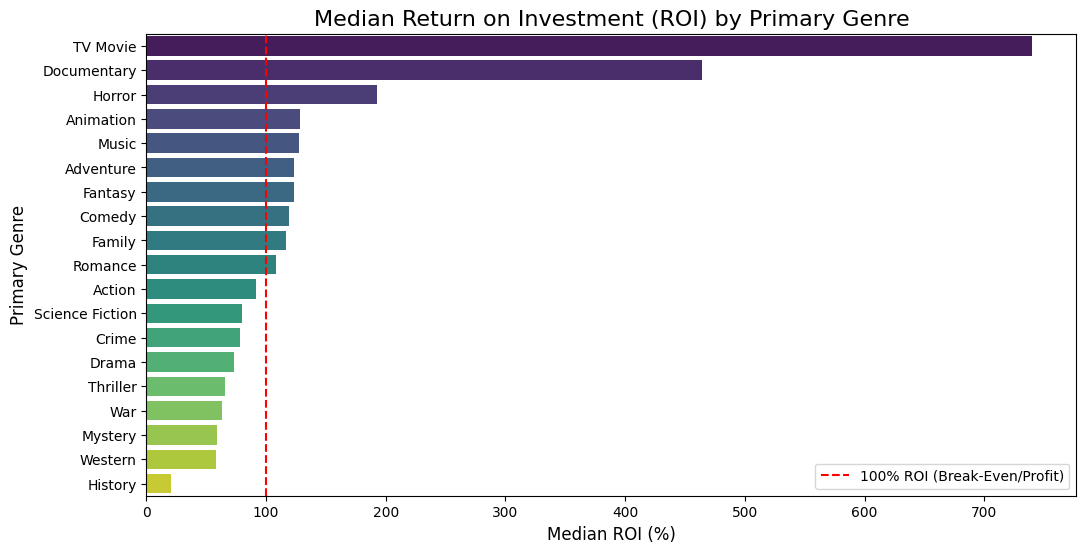

In [4]:
plt.figure(figsize=(12, 6))

# Calculate the median ROI for each primary genre
genre_roi = df.groupby('primary_genre')['roi_percentage'].median().sort_values(ascending=False)


# Bar chart
sns.barplot(x=genre_roi.values, y=genre_roi.index, palette="viridis")
plt.title('Median Return on Investment (ROI) by Primary Genre', fontsize=16)
plt.xlabel('Median ROI (%)', fontsize=12)
plt.ylabel('Primary Genre', fontsize=12)
plt.axvline(x=100, color='red', linestyle='--', label='100% ROI (Break-Even/Profit)')
plt.legend()
plt.show()

What is the optimal movie length?
### Goal: See if movie runtime affects the audience's rating (`vote_average`).

C:\Users\ANISH\AppData\Local\Temp\ipykernel_38276\761213579.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='runtime_category', y='vote_average', data=df, palette="Set2", order=labels)


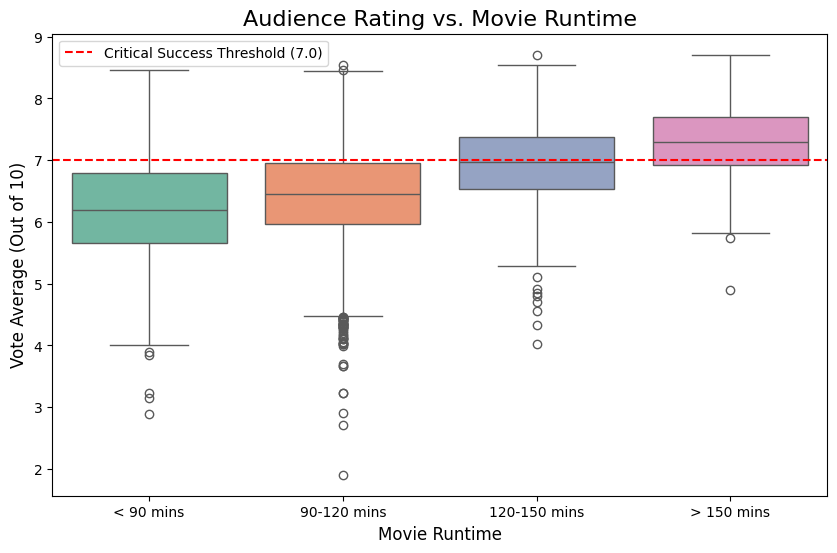

In [ ]:
plt.figure(figsize=(10, 6))

# Let's group runtime into categories (bins) for cleaner visualization
bins =[0, 90, 120, 150, df['runtime'].max()]
labels =['< 90 mins', '90-120 mins', '120-150 mins', '> 150 mins']
df['runtime_category'] = pd.cut(df['runtime'], bins=bins, labels=labels)

sns.boxplot(x='runtime_category', y='vote_average', data=df, palette="Set2", order=labels)
plt.title('Audience Rating vs. Movie Runtime', fontsize=16)
plt.xlabel('Movie Runtime', fontsize=12)
plt.ylabel('Vote Average (Out of 10)', fontsize=12)
plt.axhline(y=7.0, color='red', linestyle='--', label='Critical Success Threshold (7.0)')
plt.legend()
plt.show()



When is the best time to release a movie?
### Goal: Find out which months produce the most "Sweet Spot" movies (High ROI + High Rating).

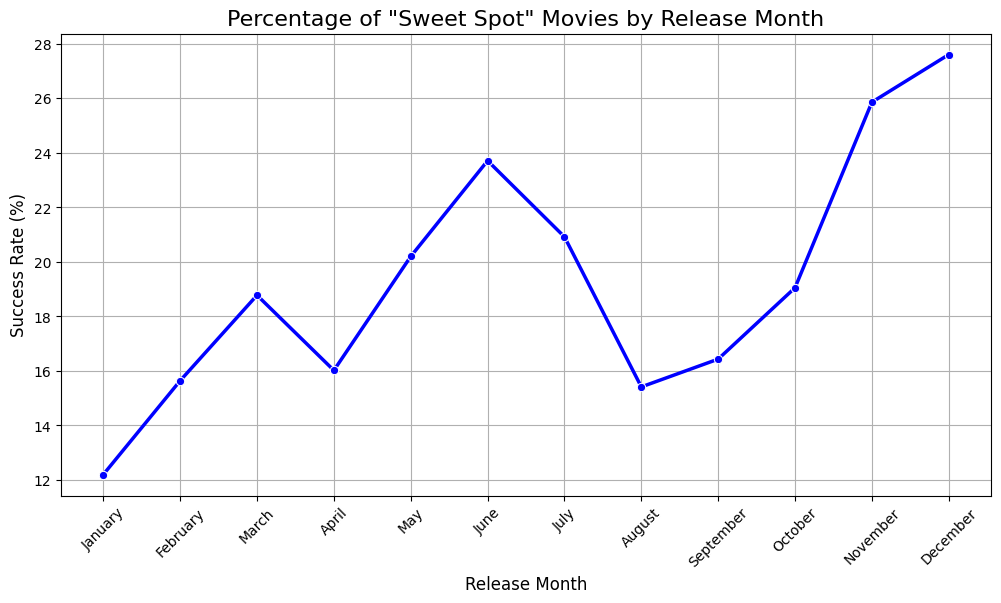

In [6]:
plt.figure(figsize=(12, 6))

months_order =['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

# Calculate percentage of movies released in each month that hit the "Sweet Spot"
sweet_spot_rates = df.groupby('release_month')['is_sweet_spot'].mean() * 100
sweet_spot_rates = sweet_spot_rates.reindex(months_order)

sns.lineplot(x=sweet_spot_rates.index, y=sweet_spot_rates.values, marker='o', color='b', linewidth=2.5)
plt.title('Percentage of "Sweet Spot" Movies by Release Month', fontsize=16)
plt.xlabel('Release Month', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Insight for report: Look for peaks. Summer (June/July) and Holidays (Nov/Dec) are usually highest.

The Reality Check (Correlation Matrix)
### Goal: Does a bigger budget actually mean a better movie?

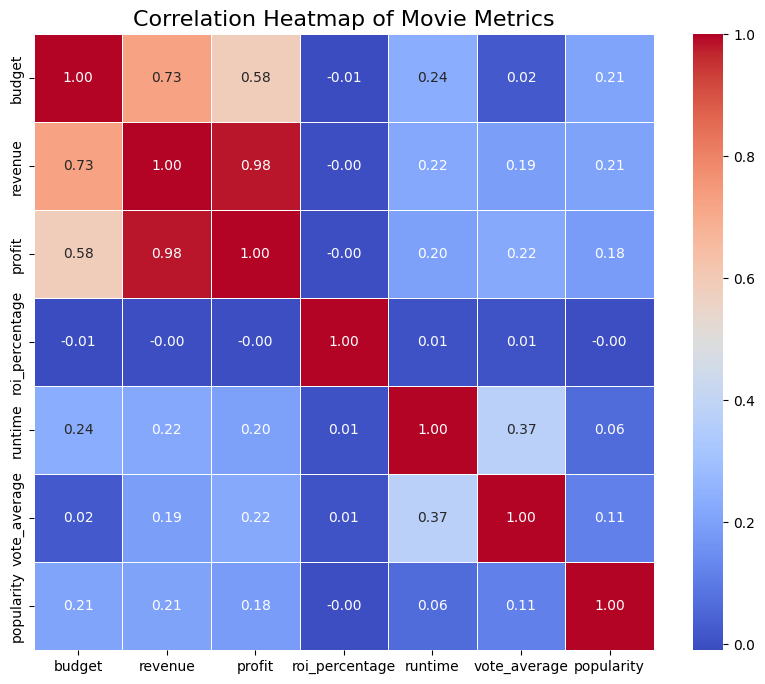

In [ ]:
plt.figure(figsize=(10, 8))

# Select only our numeric columns for correlation
numeric_cols =['budget', 'revenue', 'profit', 'roi_percentage', 'runtime', 'vote_average', 'popularity']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Movie Metrics', fontsize=16)
plt.show()


Does spending more guarantee more money?
### Goal: Visualize the direct relationship between Budget and Revenue, colored by whether the movie was a success.

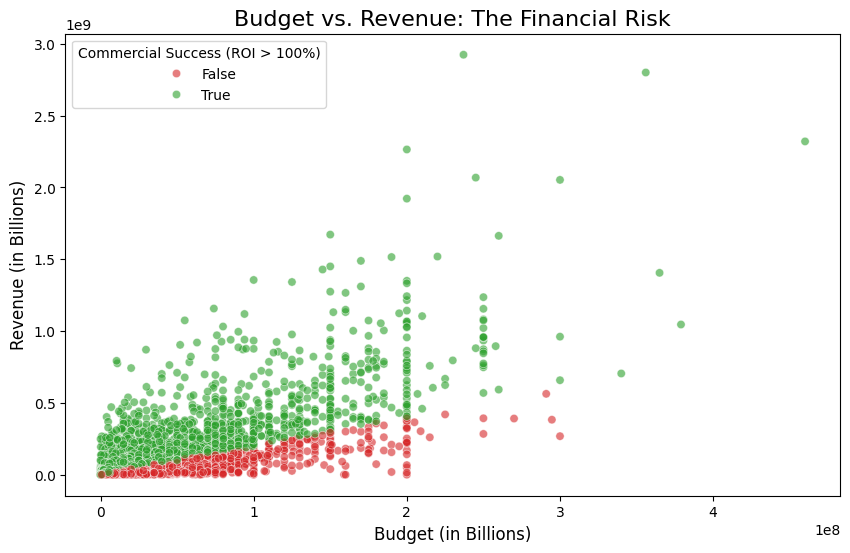

In [8]:
plt.figure(figsize=(10, 6))

# Plotting Budget vs Revenue
sns.scatterplot(
    x='budget', 
    y='revenue', 
    hue='is_commercial_success', 
    palette={True: '#2ca02c', False: '#d62728'}, # Green for success, Red for failure
    alpha=0.6, # Transparency to see overlapping dots
    data=df
)

plt.title('Budget vs. Revenue: The Financial Risk', fontsize=16)
plt.xlabel('Budget (in Billions)', fontsize=12)
plt.ylabel('Revenue (in Billions)', fontsize=12)
plt.legend(title='Commercial Success (ROI > 100%)')
plt.show()

# Insight: You will likely see a massive cluster of dots at the bottom left. 
# This proves that low-budget movies frequently achieve commercial success (green dots), 
# while high-budget movies are a massive gamble.

### Goal: Show the distribution (spread) of all movie ratings to understand the "average" landscape.

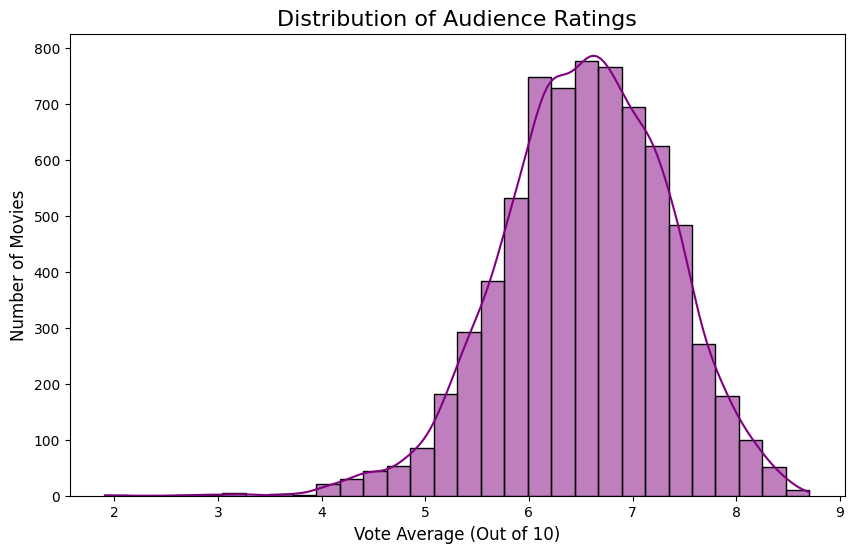

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(df['vote_average'], bins=30, kde=True, color='purple')

plt.title('Distribution of Audience Ratings', fontsize=16)
plt.xlabel('Vote Average (Out of 10)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.show()


Which day of the week is best for a premiere?

C:\Users\ANISH\AppData\Local\Temp\ipykernel_38276\2554897556.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='release_day', y='profit', data=df_filtered, order=days_order, palette="muted", inner="quartile")


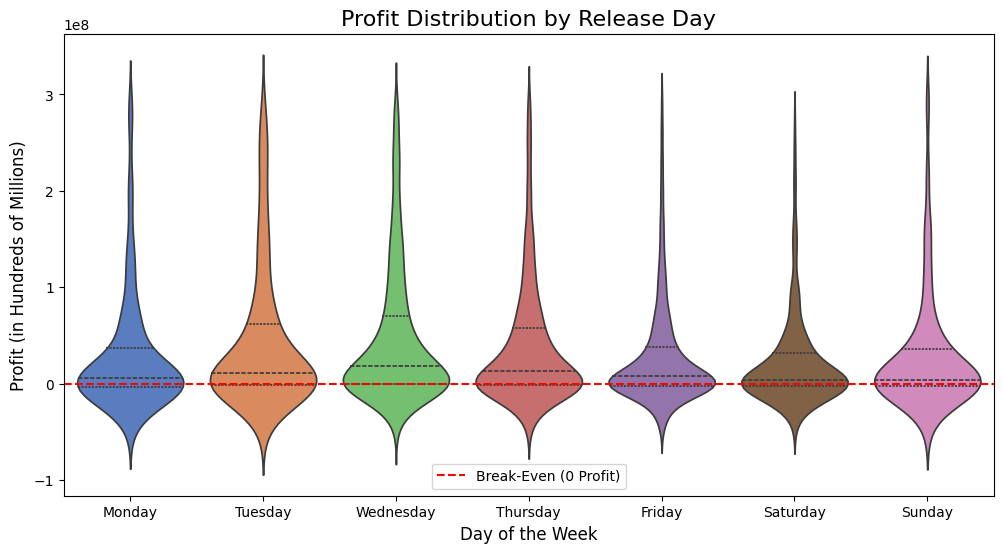

In [ ]:
plt.figure(figsize=(12, 6))

days_order =['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


sns.violinplot(x='release_day', y='profit', data=df_filtered, order=days_order, palette="muted", inner="quartile")

plt.title('Profit Distribution by Release Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Profit (in Hundreds of Millions)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', label='Break-Even (0 Profit)')
plt.legend()
plt.show()

# Insight: Fridays and Thursdays usually have the widest "bellies" (density) in the positive profit range, 
# meaning they are the standard, safest days to release.

### Goal: Show the exact proportion of movies that actually achieve our "Sweet Spot" criteria vs those that fail.

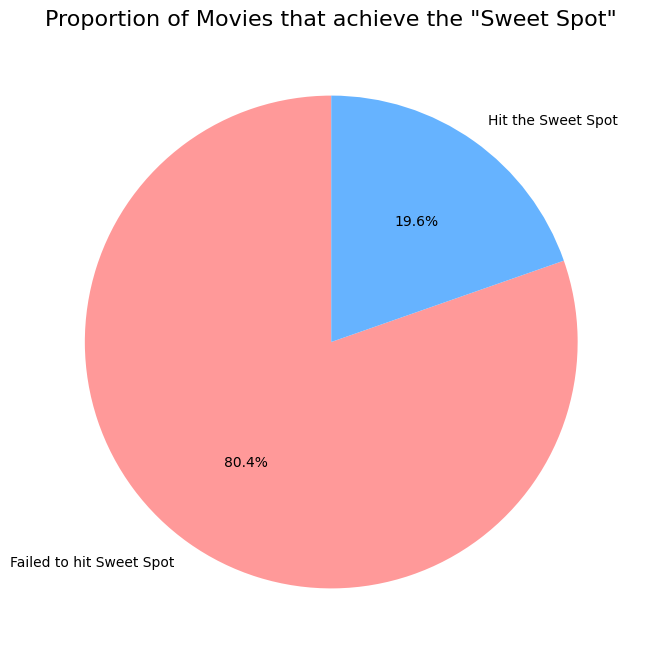

In [ ]:
plt.figure(figsize=(8, 8))

# Count how many movies hit the sweet spot
sweet_spot_counts = df['is_sweet_spot'].value_counts()

# Labels and colors
labels =['Failed to hit Sweet Spot', 'Hit the Sweet Spot']
colors =['#ff9999','#66b3ff']

plt.pie(sweet_spot_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)


plt.title('Proportion of Movies that achieve the "Sweet Spot"', fontsize=16)
plt.show()

# Insight: This visualizes the brutal reality. Usually, less than 20% of movies hit 
# both high ROI and high Ratings. This emphasizes why your playbook is needed!